In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scanpy as sc
import seaborn as sns
import sys
from matplotlib.lines import Line2D
from sccnasim.utils.gcna import load_cnas

In [3]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/cs_benchmark/base/scripts"
sys.path.append(utils_dir)
from ubase import *
from urdr import *

In [4]:
cna_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/cs_benchmark/composition/mixed/data/cna_profile.tsv'
in_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/cs_benchmark/composition/mixed/pp'
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/cs_benchmark/composition/mixed/median_libsize'
chrom_anno_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/cs_benchmark/composition/mixed/data/chrom_arm_length.3col.tsv'

In [5]:
min_cells_per_gene = 3
min_gene_mean = 0.1

In [6]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [7]:
cw_prefix = 'cw-'
gw_prefix = 'gw-'

dpi = 300

In [8]:
tool_labels = ['seed_N', 'stCNASim-cs_N', 'stCNASim-cs_T']

# Prepare Data

## Generate annotation of gene CNA type

In [9]:
os.makedirs(out_dir, exist_ok = True)

In [10]:
cna = load_cnas(cna_fn)
cna

,chrom,start,end,clone,cn_ale0,cn_ale1,region
0,1,123400001,248956422,tumor,1,2,1:123400001-248956422
1,3,1,198295559,tumor,2,1,3:1-198295559
2,4,1,190214555,tumor,2,1,4:1-190214555
3,5,1,181538259,tumor,2,1,5:1-181538259
4,6,1,170805979,tumor,1,2,6:1-170805979
5,7,1,159345973,tumor,1,2,7:1-159345973
6,8,1,45200000,tumor,0,1,8:1-45200000
7,8,45200001,145138636,tumor,1,2,8:45200001-145138636
8,12,1,35500000,tumor,1,0,12:1-35500000
9,13,17700001,114364328,tumor,2,0,13:17700001-114364328


In [11]:
adata = ad.read_h5ad(os.path.join(in_dir, "cs_normal.h5ad"))
adata

AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell_type', 'cell'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'

In [12]:
gene_anno = adata.var.copy()
gene_anno['gene'] = gene_anno['feature']
gene_anno['gene_cna_type'] = 'N.A.'
gene_anno

,chrom,start,end,feature,strand,gene,gene_cna_type
MIR1302-2HG,1,29554,31109,MIR1302-2HG,+,MIR1302-2HG,N.A.
FAM138A,1,34554,36081,FAM138A,-,FAM138A,N.A.
OR4F5,1,65419,71585,OR4F5,+,OR4F5,N.A.
AL627309.1,1,89295,133723,AL627309.1,-,AL627309.1,N.A.
AL627309.3,1,89551,91105,AL627309.3,-,AL627309.3,N.A.
...,...,...,...,...,...,...,...
ARRDC1-AS1,9,137615332,137618906,ARRDC1-AS1,-,ARRDC1-AS1,N.A.
EHMT1,9,137618963,137870016,EHMT1,+,EHMT1,N.A.
AL772363.1,9,137867925,137892570,AL772363.1,-,AL772363.1,N.A.
CACNA1B,9,137877789,138124624,CACNA1B,+,CACNA1B,N.A.


In [13]:
def is_cna_feature(x, df):
    chrom, start, end = x["chrom"], x["start"], x["end"]
    d = df[(df["chrom"] == chrom) & (df["start"] <= end) & (df["end"] >= start)]
    return(d.shape[0] > 0)

In [14]:
# Neutral genes
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

gene_anno.loc[~(gene_anno['gene'].isin(cna_genes)), 'gene_cna_type'] = 'Neutral'
gene_anno['gene_cna_type'].value_counts()

(13521,)


gene_cna_type
Neutral    18774
N.A.       13521
Name: count, dtype: int64

In [15]:
# Gain genes
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] > 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

assert np.all(gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] == 'N.A.')
gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] = 'Gain'
gene_anno['gene_cna_type'].value_counts()

(11332,)


gene_cna_type
Neutral    18774
Gain       11332
N.A.        2189
Name: count, dtype: int64

In [16]:
# Loss genes
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] < 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

assert np.all(gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] == 'N.A.')
gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] = 'Loss'
gene_anno['gene_cna_type'].value_counts()

(959,)


gene_cna_type
Neutral    18774
Gain       11332
N.A.        1230
Loss         959
Name: count, dtype: int64

In [17]:
# LOH genes
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] == 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

assert np.all(gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] == 'N.A.')
gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] = 'LOH'
gene_anno['gene_cna_type'].value_counts()

(1230,)


gene_cna_type
Neutral    18774
Gain       11332
LOH         1230
Loss         959
Name: count, dtype: int64

## Load adata files

In [18]:
seed_normal_fn = os.path.join(in_dir, "seed_normal.h5ad")
cs_normal_fn = os.path.join(in_dir, "cs_normal.h5ad")
cs_tumor_fn = os.path.join(in_dir, "cs_tumor.h5ad")

In [19]:
seed_normal = ad.read_h5ad(seed_normal_fn)
print(seed_normal)

cs_normal = ad.read_h5ad(cs_normal_fn)
print(cs_normal)

cs_tumor = ad.read_h5ad(cs_tumor_fn)
print(cs_tumor)

AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell_type', 'cell'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell_type', 'cell'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'


## Load chrom annotations

In [20]:
chrom_anno = pd.read_csv(chrom_anno_fn, sep = '\t')
chrom_anno

,chrom,q_arm_start,q_arm_end
0,1,123400000,248956422
1,2,93900000,242193529
2,3,90900000,198295559
3,4,50000000,190214555
4,5,48800000,181538259
5,6,59800000,170805979
6,7,60100000,159345973
7,8,45200000,145138636
8,9,43000000,138394717
9,10,39800000,133797422


# Get metrics

In [21]:
mv = get_gw_metrics_group(
    X_lst = [seed_normal.X, cs_normal.X, cs_tumor.X],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), cs_normal.var['feature'].to_numpy(),
             cs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean,var,cv,zero_prop,group,feature
0,0.000000,0.000000,0.000000,1.000000,seed_N,MIR1302-2HG
1,0.000000,0.000000,0.000000,1.000000,seed_N,FAM138A
2,0.000000,0.000000,0.000000,1.000000,seed_N,OR4F5
3,0.001667,0.001664,24.474475,0.998333,seed_N,AL627309.1
4,0.000000,0.000000,0.000000,1.000000,seed_N,AL627309.3
...,...,...,...,...,...,...
96880,0.095000,0.085975,3.086473,0.905000,stCNASim-cs_T,ARRDC1-AS1
96881,0.241667,0.276597,2.176242,0.786667,stCNASim-cs_T,EHMT1
96882,0.000000,0.000000,0.000000,1.000000,stCNASim-cs_T,AL772363.1
96883,0.000000,0.000000,0.000000,1.000000,stCNASim-cs_T,CACNA1B


In [22]:
tmp = mv[["group", "feature", "mean", "var", "cv", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_dir, gw_prefix + "metric_values_raw.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

# Filter genes

In [23]:
mv_seed = mv.loc[mv['group'] == 'seed_N'].copy()
mv_seed['gene'] = mv_seed['feature']
mv_seed

,mean,var,cv,zero_prop,group,feature,gene
0,0.000000,0.000000,0.000000,1.000000,seed_N,MIR1302-2HG,MIR1302-2HG
1,0.000000,0.000000,0.000000,1.000000,seed_N,FAM138A,FAM138A
2,0.000000,0.000000,0.000000,1.000000,seed_N,OR4F5,OR4F5
3,0.001667,0.001664,24.474475,0.998333,seed_N,AL627309.1,AL627309.1
4,0.000000,0.000000,0.000000,1.000000,seed_N,AL627309.3,AL627309.3
...,...,...,...,...,...,...,...
32290,0.078333,0.072197,3.430154,0.921667,seed_N,ARRDC1-AS1,ARRDC1-AS1
32291,0.233333,0.235556,2.080031,0.791667,seed_N,EHMT1,EHMT1
32292,0.000000,0.000000,0.000000,1.000000,seed_N,AL772363.1,AL772363.1
32293,0.001667,0.001664,24.474475,0.998333,seed_N,CACNA1B,CACNA1B


In [24]:
n_cell = seed_normal.shape[0]
cutoff = 1 - min_cells_per_gene / n_cell
print(cutoff)
flag = mv_seed['zero_prop'] >= cutoff
n_gene = np.sum(flag)
print("%d genes will be excluded (min_cells_per_gene = %d)" % (n_gene, min_cells_per_gene))

0.995
18269 genes will be excluded (min_cells_per_gene = 3)


In [25]:
flag = mv_seed['mean'] < min_gene_mean
n_gene = np.sum(flag)
print("%d genes will be excluded (min_gene_mean = %f)" % (n_gene, min_gene_mean))

24683 genes will be excluded (min_gene_mean = 0.100000)


In [26]:
flag = mv_seed['zero_prop'] >= 1 - min_cells_per_gene / n_cell
flag |= mv_seed['mean'] < min_gene_mean
n_gene = np.sum(flag)
print("%d genes will be excluded (min_cells_per_gene = %d; min_gene_mean = %f)" % (n_gene, min_cells_per_gene, min_gene_mean))

24683 genes will be excluded (min_cells_per_gene = 3; min_gene_mean = 0.100000)


In [27]:
flag = mv_seed['zero_prop'] >= 1 - min_cells_per_gene / n_cell
flag |= mv_seed['mean'] < min_gene_mean
valid_genes = mv_seed.loc[~flag, 'feature'].to_numpy()
valid_genes.shape

(7612,)

# Subset adata and normalize total counts

In [28]:
seed_normal = seed_normal[:, seed_normal.var['feature'].isin(valid_genes)].copy()
print(seed_normal)

cs_normal = cs_normal[:, cs_normal.var['feature'].isin(valid_genes)].copy()
print(cs_normal)

cs_tumor = cs_tumor[:, cs_tumor.var['feature'].isin(valid_genes)].copy()
print(cs_tumor)

AnnData object with n_obs × n_vars = 600 × 7612
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 7612
    obs: 'cell_type', 'cell'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 7612
    obs: 'cell_type', 'cell'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'


In [29]:
total_counts = np.array([])
for adata in [seed_normal, cs_normal, cs_tumor]:
    counts = adata.X.sum(axis = 1)
    counts = np.array(counts).reshape(-1)
    total_counts = np.concatenate((total_counts, counts))
median_total_counts = np.ceil(np.median(total_counts))
median_total_counts

9488.0

In [30]:
# seed data
total_counts = np.array([])
for adata in [seed_normal]:
    counts = adata.X.sum(axis = 1)
    counts = np.array(counts).reshape(-1)
    total_counts = np.concatenate((total_counts, counts))
median_total_counts = np.ceil(np.median(total_counts))
print(median_total_counts)

seed_normal.X = seed_normal.X.astype('float32')
sc.pp.normalize_total(seed_normal, target_sum = median_total_counts)

9030.0


In [31]:
# two cs count matrices
total_counts = np.array([])
for adata in [cs_normal, cs_tumor]:
    counts = adata.X.sum(axis = 1)
    counts = np.array(counts).reshape(-1)
    total_counts = np.concatenate((total_counts, counts))
median_total_counts = np.ceil(np.median(total_counts))
print(median_total_counts)

cs_normal.X = cs_normal.X.astype('float32')
sc.pp.normalize_total(cs_normal, target_sum = median_total_counts)

cs_tumor.X = cs_tumor.X.astype('float32')
sc.pp.normalize_total(cs_tumor, target_sum = median_total_counts)

9669.0


# Re-calculate metrics

In [32]:
mv = get_gw_metrics_group(
    X_lst = [seed_normal.X, cs_normal.X, cs_tumor.X],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), cs_normal.var['feature'].to_numpy(), cs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean,var,cv,zero_prop,group,feature
0,0.229891,0.262500,2.228658,0.793333,seed_N,NOC2L
1,0.105509,0.120962,3.296341,0.898333,seed_N,HES4
2,0.434755,0.532121,1.677880,0.651667,seed_N,ISG15
3,0.343594,0.342886,1.704234,0.685000,seed_N,AGRN
4,0.088896,0.088879,3.353646,0.903333,seed_N,C1orf159
...,...,...,...,...,...,...
22831,0.146573,0.142738,2.577608,0.840000,stCNASim-cs_T,PNPLA7
22832,0.893937,0.895517,1.058595,0.391667,stCNASim-cs_T,MRPL41
22833,0.083609,0.067137,3.099041,0.893333,stCNASim-cs_T,DPH7
22834,0.248785,0.266283,2.074182,0.756667,stCNASim-cs_T,ARRDC1


In [33]:
tmp = mv[["group", "feature", "mean", "var", "cv", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_dir, gw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

# Calculate log2FC

In [34]:
pairs = [
    ("stCNASim-cs_T", "stCNASim-cs_N")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [35]:
st_log2fc = stat_log2fc(
    data = mv,
    metric = "mean", group = "group", gvars = selected_gvars
)
genes = mv.loc[mv['group'] == 'seed_N', 'feature'].to_numpy()
st_log2fc['gene'] = np.tile(genes, int(st_log2fc.shape[0] / len(genes)))
print(st_log2fc)


tmp = st_log2fc.copy()
tmp.to_csv(
    os.path.join(out_dir, gw_prefix + "log2fc-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                  x              y    mean_x    mean_y    log2FC      gene
0     stCNASim-cs_N  stCNASim-cs_T  0.226699  0.185382 -0.290279     NOC2L
1     stCNASim-cs_N  stCNASim-cs_T  0.104881  0.088101 -0.251519      HES4
2     stCNASim-cs_N  stCNASim-cs_T  0.445561  0.328653 -0.439058     ISG15
3     stCNASim-cs_N  stCNASim-cs_T  0.420105  0.332831 -0.335957      AGRN
4     stCNASim-cs_N  stCNASim-cs_T  0.113571  0.072440 -0.648732  C1orf159
...             ...            ...       ...       ...       ...       ...
7607  stCNASim-cs_N  stCNASim-cs_T  0.159786  0.146573 -0.124521    PNPLA7
7608  stCNASim-cs_N  stCNASim-cs_T  1.076421  0.893937 -0.267997    MRPL41
7609  stCNASim-cs_N  stCNASim-cs_T  0.091457  0.083609 -0.129442      DPH7
7610  stCNASim-cs_N  stCNASim-cs_T  0.330293  0.248785 -0.408844    ARRDC1
7611  stCNASim-cs_N  stCNASim-cs_T  0.210452  0.210694  0.001658     EHMT1

[7612 rows x 6 columns]


In [36]:
st_log2fc_valid = st_log2fc.loc[st_log2fc['gene'].isin(valid_genes)].copy()
st_log2fc_valid = st_log2fc_valid.merge(gene_anno, on = 'gene', how = 'left')
st_log2fc_valid

,x,y,mean_x,mean_y,log2FC,gene,chrom,start,end,feature,strand,gene_cna_type
0,stCNASim-cs_N,stCNASim-cs_T,0.226699,0.185382,-0.290279,NOC2L,1,944204,959309,NOC2L,-,Neutral
1,stCNASim-cs_N,stCNASim-cs_T,0.104881,0.088101,-0.251519,HES4,1,998962,1000172,HES4,-,Neutral
2,stCNASim-cs_N,stCNASim-cs_T,0.445561,0.328653,-0.439058,ISG15,1,1001138,1014541,ISG15,+,Neutral
3,stCNASim-cs_N,stCNASim-cs_T,0.420105,0.332831,-0.335957,AGRN,1,1020123,1056118,AGRN,+,Neutral
4,stCNASim-cs_N,stCNASim-cs_T,0.113571,0.072440,-0.648732,C1orf159,1,1081818,1116361,C1orf159,-,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...
7607,stCNASim-cs_N,stCNASim-cs_T,0.159786,0.146573,-0.124521,PNPLA7,9,137459953,137550534,PNPLA7,-,Neutral
7608,stCNASim-cs_N,stCNASim-cs_T,1.076421,0.893937,-0.267997,MRPL41,9,137551199,137552555,MRPL41,+,Neutral
7609,stCNASim-cs_N,stCNASim-cs_T,0.091457,0.083609,-0.129442,DPH7,9,137554904,137578935,DPH7,-,Neutral
7610,stCNASim-cs_N,stCNASim-cs_T,0.330293,0.248785,-0.408844,ARRDC1,9,137605654,137615360,ARRDC1,+,Neutral


# Plot RDR signals

In [37]:
chr_info = {}
for i in range(chrom_anno.shape[0]):
    chr_info[str(chrom_anno['chrom'].iloc[i])] = (
        chrom_anno['q_arm_end'].iloc[i],
        chrom_anno['q_arm_start'].iloc[i]
    )
chr_info

{'1': (248956422, 123400000),
 '2': (242193529, 93900000),
 '3': (198295559, 90900000),
 '4': (190214555, 50000000),
 '5': (181538259, 48800000),
 '6': (170805979, 59800000),
 '7': (159345973, 60100000),
 '8': (145138636, 45200000),
 '9': (138394717, 43000000),
 '10': (133797422, 39800000),
 '11': (135086622, 53400000),
 '12': (133275309, 35500000),
 '13': (114364328, 17700000),
 '14': (107043718, 17200000),
 '15': (101991189, 19000000),
 '16': (90338345, 36800000),
 '17': (83257441, 25100000),
 '18': (80373285, 18500000),
 '19': (58617616, 26200000),
 '20': (64444167, 28100000),
 '21': (46709983, 12000000),
 '22': (50818468, 15000000)}

In [38]:
def plot_rdr(st_log2fc, out_fn, figsize = (10, 1), dpi = 300):
    chr_list = list(chr_info.keys())
    x_total = 0
    chr_bounds = {}
    arm_bounds = []
    gap = 1e7      # otherwise, points could overlap bound lines.
    fontsize = 7

    for chr_num in chr_list:
        len_chr, cen_pos = chr_info[chr_num]
        p_start = x_total
        q_start = x_total + cen_pos + gap
        chr_end = x_total + len_chr + gap*2
        chr_bounds[chr_num] = (p_start, q_start, chr_end)
        arm_bounds.append(q_start)
        x_total = chr_end

    color_dict = {
        "Gain": "#D14050",
        "Loss": "#0078BB",
        "LOH": "#40B5A8",
        "Neutral": '#B3B3B3'
    }

    df = pd.DataFrame(data = {
        'chr': st_log2fc['chrom'].astype(str),
        'x': (st_log2fc['start'] + st_log2fc['end']) / 2.0,
        'log2FC': st_log2fc['log2FC'],
        'cnv_state': st_log2fc['gene_cna_type']
    })
    for chr_num in chr_list:
        df.loc[df['chr'] == chr_num, 'x'] += chr_bounds[chr_num][0] + gap

    # Plot
    fig, ax = plt.subplots(1, 1, figsize = figsize, dpi = dpi)

    ax.axhline(0, color = 'black', lw = 1, ls = '--', alpha = 0.7)
    for chr_num in chr_list:    # Chromosome and arm borders
        ax.axvline(chr_bounds[chr_num][0], color = "#bbbbbb", lw = 1.0, zorder = 0)
    for pos in arm_bounds:
        ax.axvline(pos, color = "#e0e0e0", lw = 0.5, ls = '--', zorder = 0)

    # Neutral genes
    pointsize = 2
    neu = df[df.cnv_state == "Neutral"]
    sns.scatterplot(
        data = neu, x = "x", y = "log2FC", 
        color = color_dict["Neutral"], s = pointsize, alpha = 0.9, 
        ax = ax, zorder = 1
    )
    # CNA genes
    for state in ["Gain", "Loss", "LOH"]:
        sub = df[df.cnv_state == state]
        sns.scatterplot(
            data = sub, x = "x", y = "log2FC", color = color_dict[state], 
            s = pointsize, alpha = 0.9, 
            ax = ax, zorder = 2
        )
    # Median line.
    for chr_num in chr_list:
        sub = df.loc[(df.chr == chr_num) & (df.x < chr_bounds[chr_num][1])].sort_values("x")
        ax.hlines(sub.log2FC.median(), xmin = sub.x.min(), xmax = sub.x.max(), color = "#8B0000", lw = 1, zorder = 3)
        sub = df.loc[(df.chr == chr_num) & (df.x >= chr_bounds[chr_num][1])].sort_values("x")
        ax.hlines(sub.log2FC.median(), xmin = sub.x.min(), xmax = sub.x.max(), color = "#8B0000", lw = 1, zorder = 3)

    markersize = fontsize - 1.5
    legend_elements = [
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Gain"], 
               markersize = markersize, label = 'Gain'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Loss"], 
               markersize = markersize, label = 'Loss'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["LOH"], 
               markersize = markersize, label = 'LOH'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Neutral"], 
               markersize = markersize, label = 'Neutral')
    ]
    fig.legend(
        handles = legend_elements, loc = "center left", bbox_to_anchor = (0.975, 0.5), 
        frameon = False, fontsize = fontsize, handletextpad = 0.1)

    for ax in [ax]:
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

    ax.set_xlabel(None)
    ax.set_ylabel(r"Log$_2$FC", fontsize = fontsize)
    ax.set_xticks([(v[0]+v[2])/2 for v in chr_bounds.values()])
    ax.set_xticklabels([str(c) for c in chr_list], fontsize = fontsize)
    ax.tick_params(axis = 'x', length = 0)
    ax.set_xlim(0, chr_bounds['22'][-1])
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize - 1
    )

    plt.tight_layout()
    fig.savefig(out_fn, dpi = dpi, bbox_inches = 'tight')

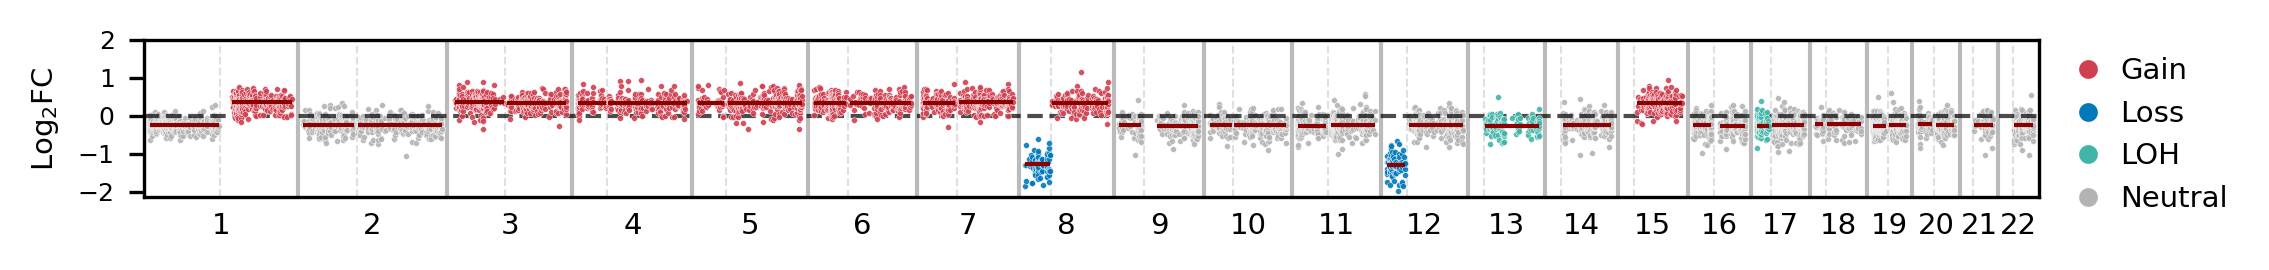

In [39]:
st_log2fc = st_log2fc_valid.loc[st_log2fc_valid['x'] == 'stCNASim-cs_N'].copy()
fn = os.path.join(out_dir, gw_prefix + "rdr-stCNASim-cs.png")
plot_rdr(st_log2fc, out_fn = fn, figsize = (7, 1))

### Re-centering

-0.25171834


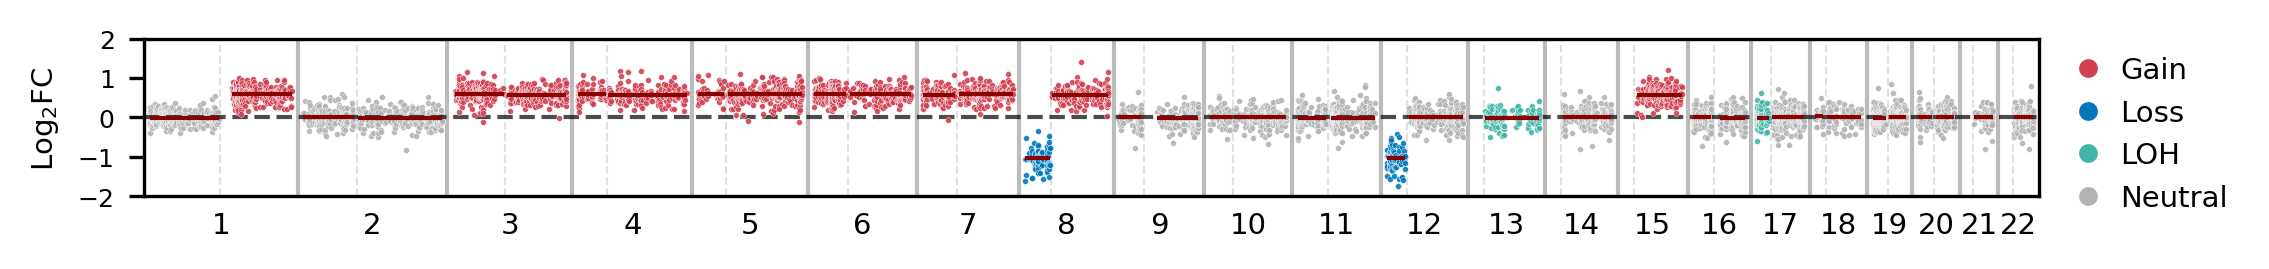

In [40]:
st_log2fc = st_log2fc_valid.loc[st_log2fc_valid['x'] == 'stCNASim-cs_N'].copy()
baseline = st_log2fc.loc[st_log2fc['gene_cna_type'] == 'Neutral', 'log2FC'].median()
print(baseline)

st_log2fc['log2FC'] -= baseline
fn = os.path.join(out_dir, gw_prefix + "rdr-stCNASim-cs-recentering.png")
plot_rdr(st_log2fc, out_fn = fn, figsize = (7, 1))